#Oliwier Bogdański 21181


Lab 3

In [52]:
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds


In [53]:
mnist_dataset, mnist_info = tfds.load(name="mnist", as_supervised=True, with_info=True)
mnist_train, mnist_test = mnist_dataset["train"], mnist_dataset["test"]
num_validation_samples = 0.1 * mnist_info.splits['train'].num_examples
num_validation_samples = tf.cast(num_validation_samples, tf.int64)
num_test_samples = mnist_info.splits['test'].num_examples
num_test_samples = tf.cast(num_test_samples, tf.int64)


In [54]:
def scale(image, label):
  image = tf.cast(image, tf.float32)
  image /= 255.
  return image, label

scaled_train_and_validation_data = mnist_train.map(scale)
test_data = mnist_test.map(scale)

In [55]:
BUFFER_SIZE = 1000
shuffled_train_and_validation_data = scaled_train_and_validation_data.shuffle(BUFFER_SIZE)
validation_data = shuffled_train_and_validation_data.take(num_validation_samples)
train_data = shuffled_train_and_validation_data.skip(num_validation_samples)

In [56]:
BATCH_SIZE = 100
train_data = train_data.batch(BATCH_SIZE)
validation_data = validation_data.batch(num_validation_samples)
test_data = test_data.batch(num_test_samples)

validation_inputs, validation_targets = next(iter(validation_data))
print(validation_inputs.shape, validation_targets.shape)

(6000, 28, 28, 1) (6000,)


In [57]:
input_size = 784
output_size = 10

hidden_layer_size = 50

model = tf.keras.Sequential([
  tf.keras.layers.Flatten(input_shape=(28,28,1)),
  tf.keras.layers.Dense(hidden_layer_size, activation='relu'),
  tf.keras.layers.Dense(hidden_layer_size, activation='relu'),
  tf.keras.layers.Dense(output_size, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [58]:
NUM_EPOCHS = 30

early_stopping = tf.keras.callbacks.EarlyStopping(patience=2)

model.fit(train_data,
          epochs=NUM_EPOCHS,
          callbacks=[early_stopping],
          validation_data=(validation_inputs, validation_targets),
          verbose=1
          )

Epoch 1/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.8846 - loss: 0.4120 - val_accuracy: 0.9362 - val_loss: 0.2114
Epoch 2/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9492 - loss: 0.1744 - val_accuracy: 0.9508 - val_loss: 0.1634
Epoch 3/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9600 - loss: 0.1348 - val_accuracy: 0.9590 - val_loss: 0.1439
Epoch 4/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9685 - loss: 0.1092 - val_accuracy: 0.9607 - val_loss: 0.1354
Epoch 5/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9720 - loss: 0.0937 - val_accuracy: 0.9642 - val_loss: 0.1246
Epoch 6/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9758 - loss: 0.0812 - val_accuracy: 0.9670 - val_loss: 0.1189
Epoch 7/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9792 - loss: 0.0704 - val_accuracy: 0.9652 - val_loss: 0.1197
Epoch 8/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9811 - loss: 0.0624 - val_accuracy:

In [59]:
test_loss, test_accuracy = model.evaluate(test_data)
print('Test loss: {0:.2f}. Test accuracy: {1:.2f}%' .format(test_loss, test_accuracy*100.))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 983ms/step - accuracy: 0.9710 - loss: 0.1001
Test loss: 0.10. Test accuracy: 97.10%


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Prawdopodobieństwa dla klas od 0 do 9:
[[6.7452032e-07 7.6392327e-19 1.7387204e-02 9.4292861e-01 0.0000000e+00
  1.1823090e-16 1.2682623e-17 3.9683539e-02 1.6809284e-20 1.7249486e-15]]

--> ROZPOZNANA CYFRA TO: 3 <--



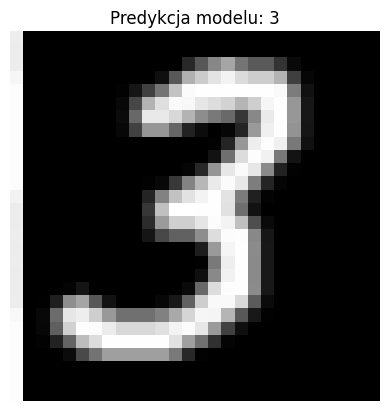

In [65]:
image_path = 'sample_data/moja_cyfra.png'

img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if img is not None:
    img_resized = cv2.resize(img, (28, 28))

    img_inverted = cv2.bitwise_not(img_resized)

    img_normalized = img_inverted / 255.0

    img_ready = np.expand_dims(img_normalized, axis=0)
    img_ready = np.expand_dims(img_ready, axis=-1)

    predictions = model.predict(img_ready)

    predicted_digit = np.argmax(predictions)

    print(f"Prawdopodobieństwa dla klas od 0 do 9:\n{predictions}")
    print(f"\n--> ROZPOZNANA CYFRA TO: {predicted_digit} <--\n")

    plt.imshow(img_resized, cmap='gray')
    plt.title(f"Predykcja modelu: {predicted_digit}")
    plt.axis('off')
    plt.show()
else:
    print(f"Nie znaleziono pliku '{image_path}'. Dodaj obrazek do środowiska Colab.")